# Globally Interconnected Solar-Wind System — 输入数据可视化 & 最优解提取

对应论文：*Globally Interconnected Solar-Wind System Addresses Future Electricity Demands* (Jiang et al., Nat. Commun. 2025)

**使用说明**
- Section 0：环境配置，修改 `DATA_DIR` 和 `RESULT_FILE` 指向你的真实数据
- Section 1–6：逐一可视化每类输入数据
- Section 7：从优化结果中提取最优解并可视化场站位置

---
## Section 0 — 环境配置与路径设置

字体名称: Source Han Sans SC


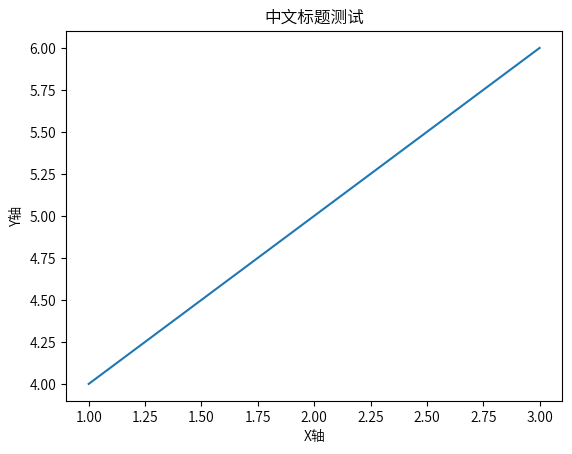

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# 指定字体文件路径
font_path = "/data4/yanxiaokai/SourceHanSansSC-Normal.otf"  # Linux 示例路径

# 关键：使用 addfont 将字体添加到 fontManager
fm.fontManager.addfont(font_path)

# 获取字体名称（不是文件名！）
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print(f"字体名称: {font_name}")

# 设置全局字体
plt.rcParams['font.family'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

# 测试
plt.plot([1, 2, 3], [4, 5, 6])
plt.title('中文标题测试')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.show()

In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager as fm
import h5py
import scipy.io

# 指定字体文件路径
font_path = "/data4/yanxiaokai/SourceHanSansSC-Normal.otf"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)  # 获取字体名称
font_name = font_prop.get_name()
print(f"字体名称: {font_name}")

# 设置全局字体
plt.rcParams["font.family"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False


import rasterio
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# ★ 修改以下路径指向你的真实数据目录
# ============================================================
DATA_DIR = "./Optimization"  # 输入数据目录
RESULT_FILE = "Resilience/Optimization_SG_2050_Res.h5"  # 优化结果 HDF5 文件
# ============================================================

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

# 20 个区域标签（与论文 Fig. S4 对应）
REGION_NAMES = [
    "Northern America",
    "Caribbean",
    "Central America",
    "Southern America",
    "Northern Europe",
    "Western Europe",
    "Southern Europe",
    "Eastern Europe",
    "Central Asia",
    "Eastern Asia",
    "Southern Asia",
    "Southeastern Asia",
    "Western Asia",
    "Australia-NZ",
    "Melanesia",
    "Northern Africa",
    "Western Africa",
    "Middle Africa",
    "Eastern Africa",
    "Southern Africa",
]

print("配置完成")

字体名称: Source Han Sans SC
配置完成


---
## Section 1 — 风电适宜性栅格 (`Global_Wind_Net_Area_Add_Egrid.tif`)

**含义**：每个 500m 像元中可安装风机的净面积占比（%），由土地覆被 + 坡度 + 道路距离 + 输电线距离四重筛选后得到


  Global_Wind_Net_Area_Add_Egrid (风电适宜性 %)
  Shape        : (180, 360)
  Lon 范围     : [-180.00°, 180.00°]
  Lat 范围     : [-90.00°, 90.00°]
  全域值域     : [0.0000, 9.9957]
  非零像元数   : 8,477
  非零均值     : 3.0856
  非零中位数   : 2.0992
  非零标准差   : 2.9292


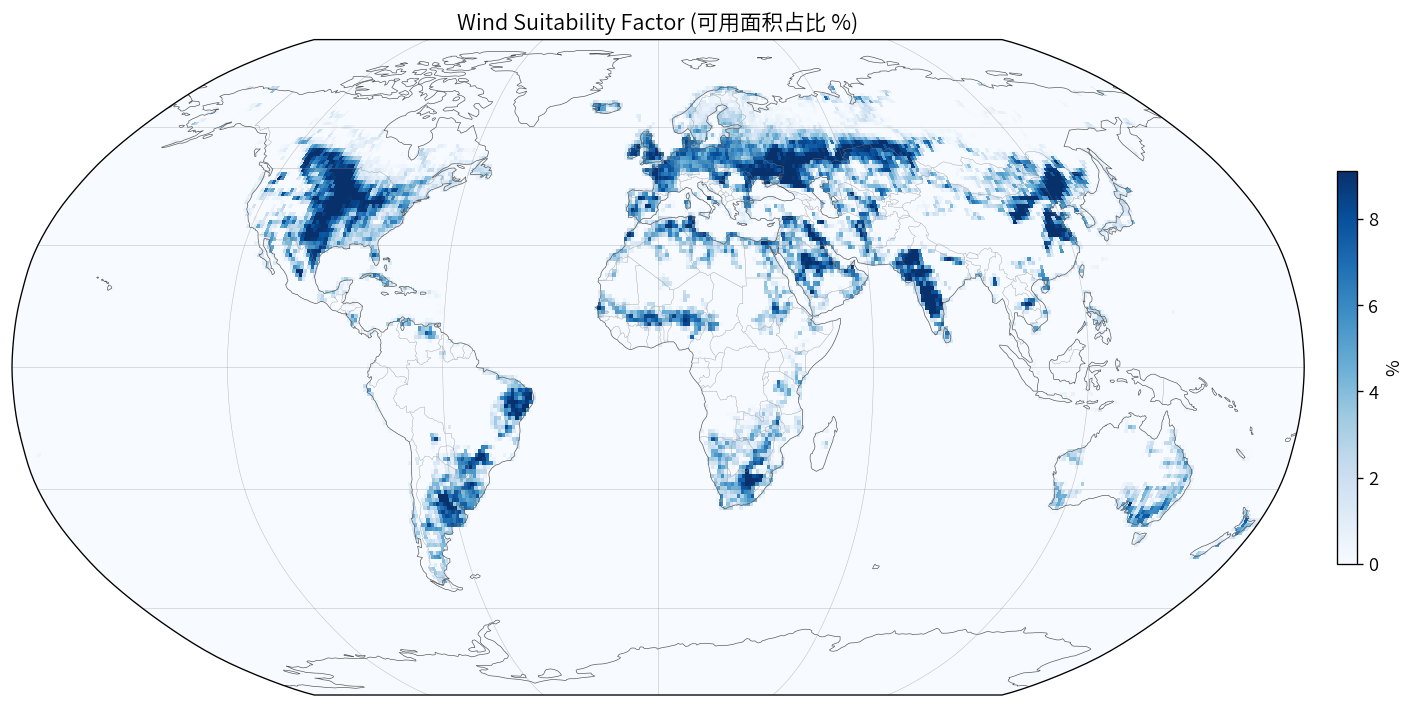

In [3]:
def load_tif(filepath):
    """读取 GeoTIFF 并返回数据、经纬度坐标"""
    with rasterio.open(filepath) as src:
        data = src.read(1).astype(np.float64)
        bounds = src.bounds  # left, bottom, right, top
        transform = src.transform
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
    lon = np.linspace(bounds.left, bounds.right, data.shape[1])
    lat = np.linspace(bounds.top, bounds.bottom, data.shape[0])
    return data, lon, lat


def print_stats(name, data, lon, lat):
    valid = data[np.isfinite(data) & (data > 0)]
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape        : {data.shape}")
    print(f"  Lon 范围     : [{lon.min():.2f}°, {lon.max():.2f}°]")
    print(f"  Lat 范围     : [{lat.min():.2f}°, {lat.max():.2f}°]")
    print(f"  全域值域     : [{np.nanmin(data):.4f}, {np.nanmax(data):.4f}]")
    print(f"  非零像元数   : {len(valid):,}")
    print(f"  非零均值     : {valid.mean():.4f}")
    print(f"  非零中位数   : {np.median(valid):.4f}")
    print(f"  非零标准差   : {valid.std():.4f}")


def plot_global_map(ax, data, lon, lat, title, cmap="YlOrRd", vmax=None, cbar_label=""):
    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color="#555")
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, color="#888")
    ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
    lon2d, lat2d = np.meshgrid(lon, lat)
    vm = vmax if vmax else np.nanpercentile(data[data > 0], 95) if np.any(data > 0) else 1
    im = ax.pcolormesh(
        lon2d, lat2d, data, cmap=cmap, vmin=0, vmax=vm, transform=ccrs.PlateCarree(), rasterized=True
    )
    plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label=cbar_label)
    ax.set_title(title, fontweight="bold")


# --- 加载数据 ---
wind_net, wlon, wlat = load_tif(os.path.join(DATA_DIR, "Global_Wind_Net_Area_Add_Egrid.tif"))
wind_net_pct = wind_net / 100.0  # 转为小数（与 MATLAB 代码一致）

print_stats("Global_Wind_Net_Area_Add_Egrid (风电适宜性 %)", wind_net, wlon, wlat)

fig, ax = plt.subplots(1, 1, figsize=(14, 6), subplot_kw={"projection": ccrs.Robinson()})

plot_global_map(
    ax,
    wind_net,
    wlon,
    wlat,
    title="Wind Suitability Factor (可用面积占比 %)",
    cmap="Blues",
    cbar_label="%",
)
plt.tight_layout()
plt.show()

---
## Section 2 — 光伏适宜性栅格 (`Global_Solar_Net_Area_Add_Egrid.tif`)

**含义**：每个像元中可安装光伏板的净面积占比（%），安装密度 74 W/m²


  Global_Solar_Net_Area_Add_Egrid (光伏适宜性 %)
  Shape        : (180, 360)
  Lon 范围     : [-180.00°, 180.00°]
  Lat 范围     : [-90.00°, 90.00°]
  全域值域     : [0.0000, 14.0497]
  非零像元数   : 9,165
  非零均值     : 1.8919
  非零中位数   : 0.7396
  非零标准差   : 2.4665


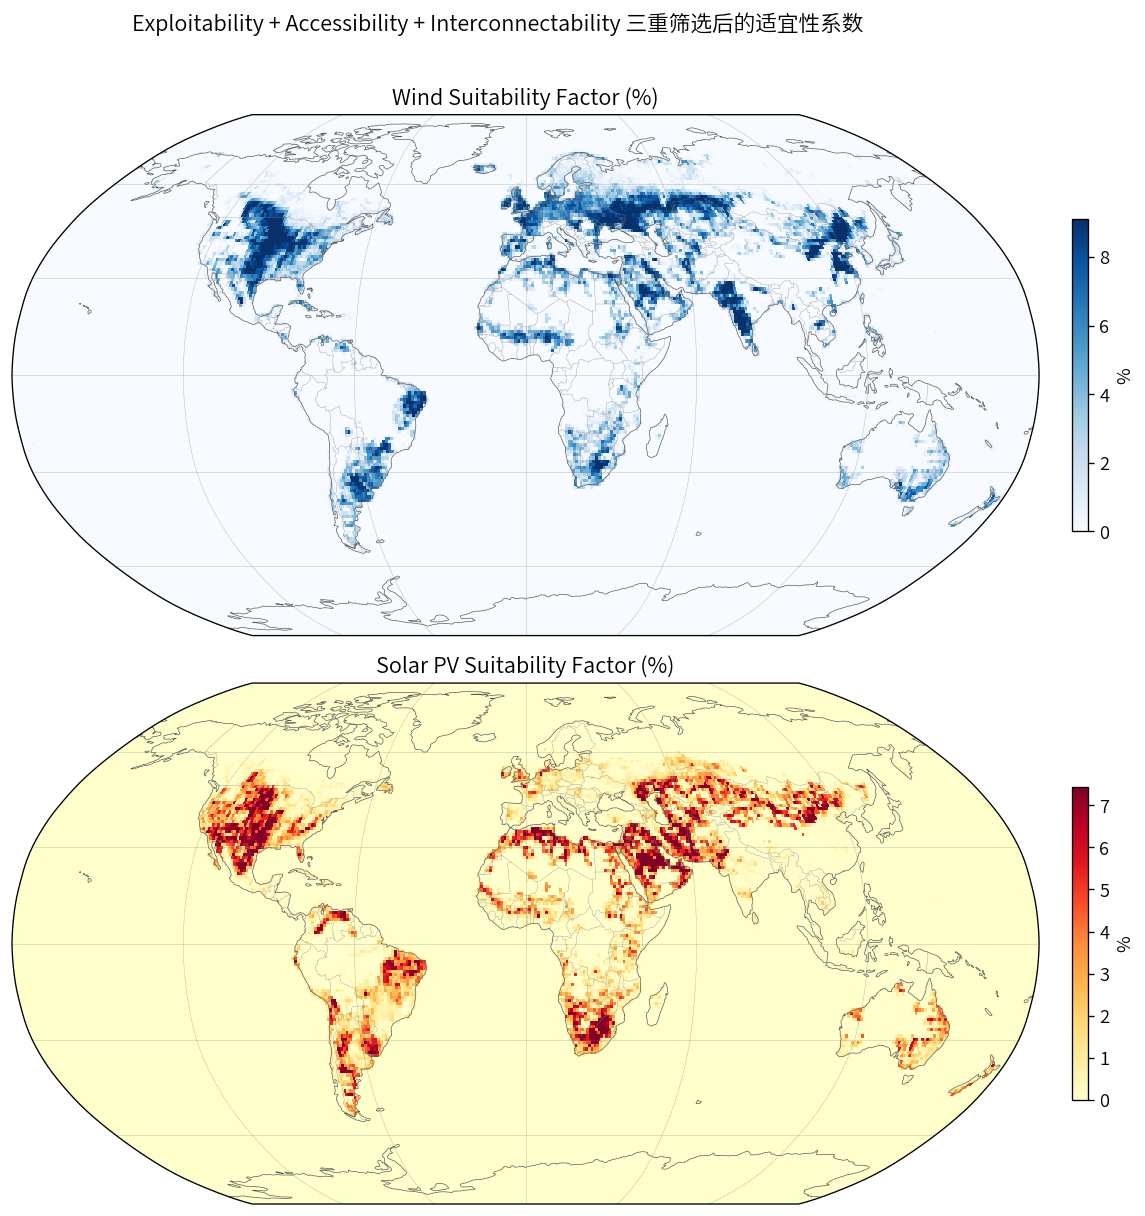

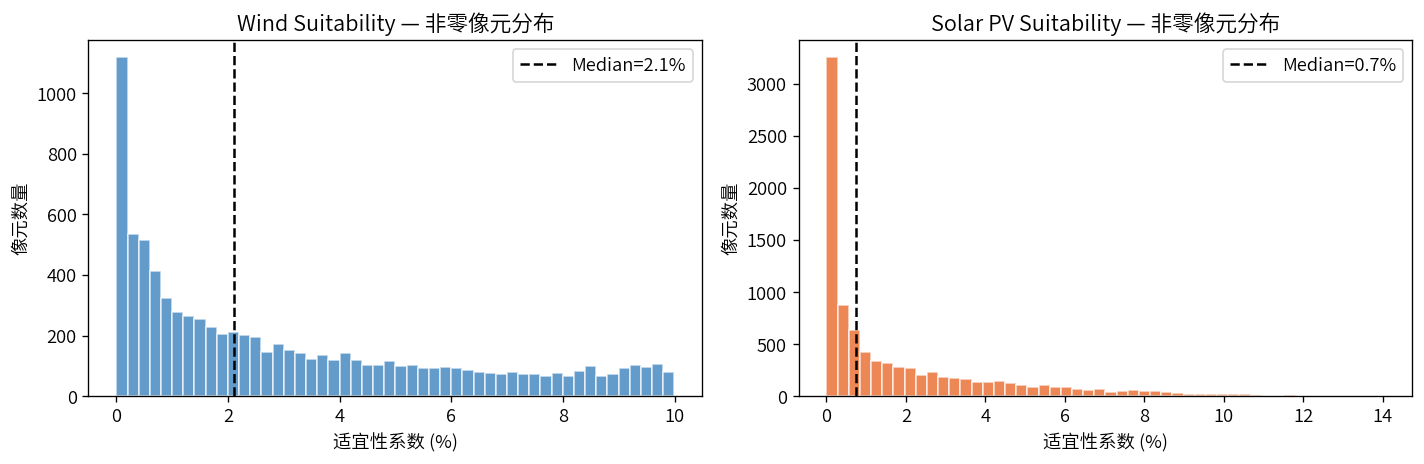

In [4]:
solar_net, slon, slat = load_tif(
    os.path.join(DATA_DIR, 'Global_Solar_Net_Area_Add_Egrid.tif'),
)

print_stats('Global_Solar_Net_Area_Add_Egrid (光伏适宜性 %)', solar_net, slon, slat)

fig, axes = plt.subplots(2, 1, figsize=(14, 10),
    subplot_kw={'projection': ccrs.Robinson()})

plot_global_map(axes[0], wind_net, wlon, wlat,
                title='Wind Suitability Factor (%)', cmap='Blues',
                cbar_label='%')
plot_global_map(axes[1], solar_net, slon, slat,
                title='Solar PV Suitability Factor (%)', cmap='YlOrRd',
                cbar_label='%')
plt.suptitle('Exploitability + Accessibility + Interconnectability 三重筛选后的适宜性系数',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 直方图对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, color, label in [
    (ax1, wind_net[wind_net>0],  '#2171b5', 'Wind'),
    (ax2, solar_net[solar_net>0], '#e6550d', 'Solar PV')
]:
    ax.hist(data.ravel(), bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{label} Suitability — 非零像元分布')
    ax.set_xlabel('适宜性系数 (%)')
    ax.set_ylabel('像元数量')
    ax.axvline(np.median(data), color='k', ls='--', lw=1.5, label=f'Median={np.median(data):.1f}%')
    ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3 — 风电容量因子时间序列 (`Global_Wind_CFs_Sel.h5`)

**含义**：筛选后 8477 个风电候选格网 × 8760 小时的 CF 矩阵，由 ERA5 历史均值（2000–2022）计算


  Global_Wind_CFs_Sel.h5  [风电容量因子]
  Shape           : (8477, 8760)  (格网数 × 8760h)
  CF 范围         : [0.0026, 1.0000]
  全域均值 CF     : 0.2506
  年均 CF（每格网均值）
    最小: 0.0201  最大: 0.8259  均值: 0.2506


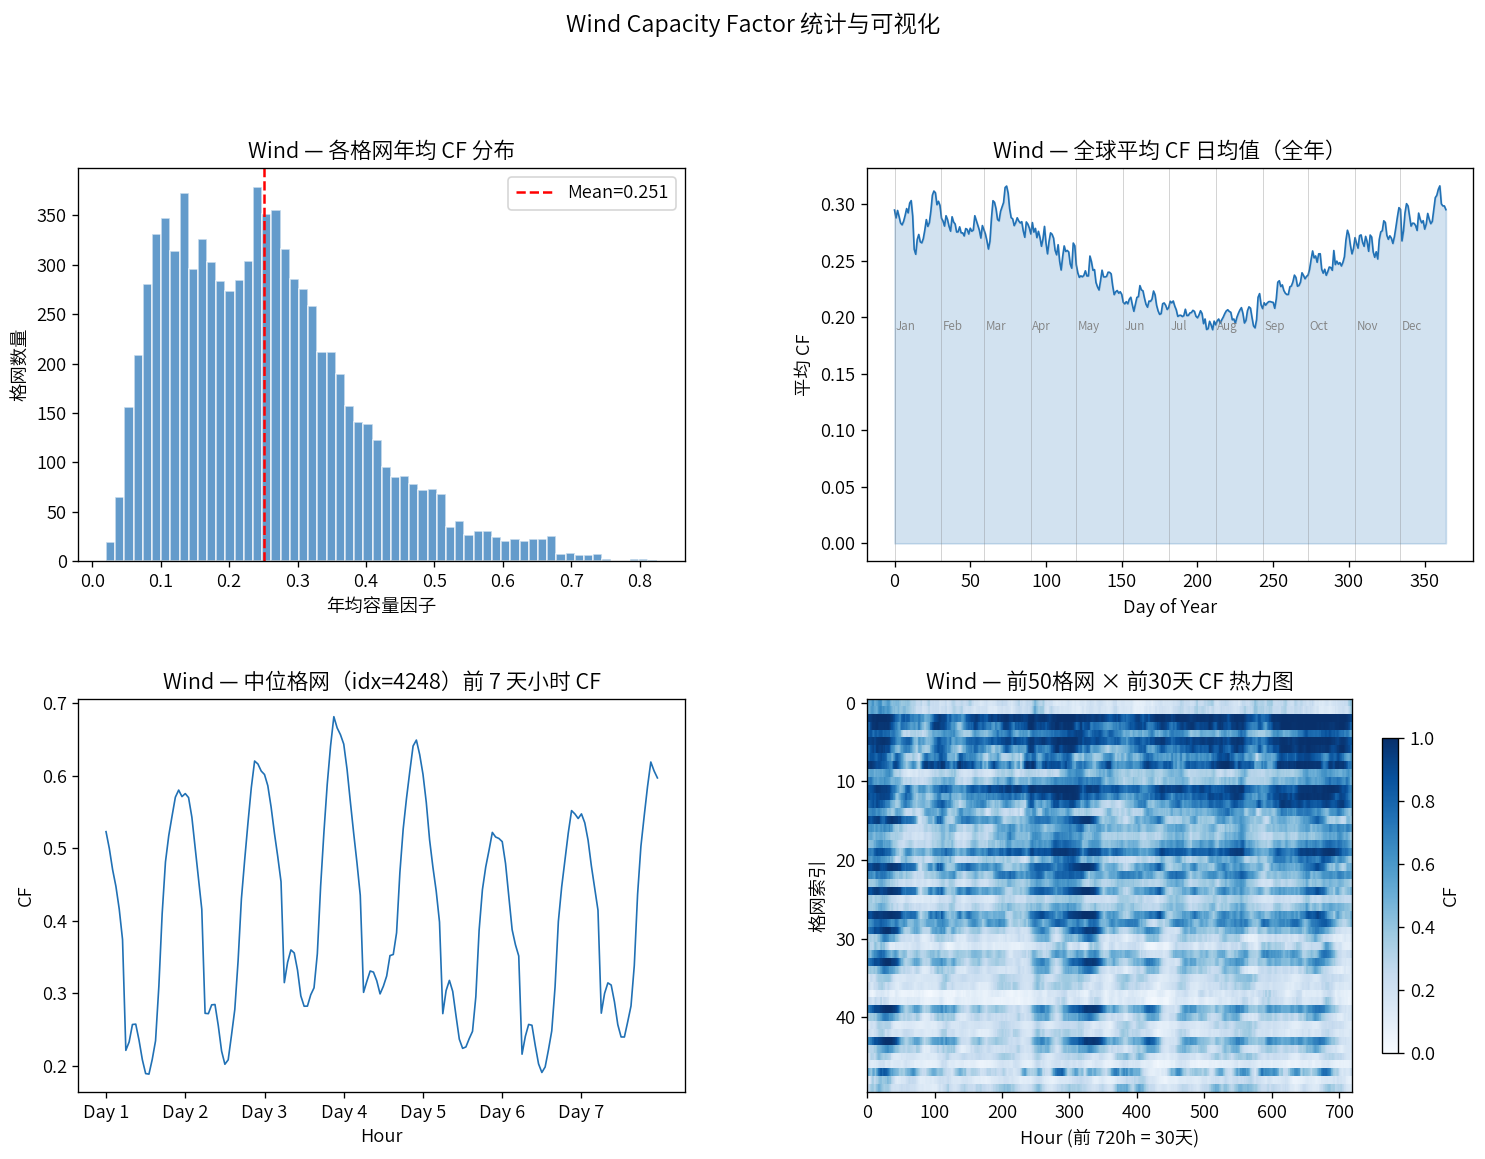

In [5]:
def load_h5_cfs(filepath, dataset):
    with h5py.File(filepath, 'r') as f:
        data = f[dataset][:].astype(np.float32)
    # Ensure shape is (n_grids, n_hours) — transpose if needed
    if data.shape[0] == 8760 and data.shape[1] != 8760:
        data = data.T
    return data


wind_cfs = load_h5_cfs(
    os.path.join(DATA_DIR, 'Global_Wind_CFs_Sel.h5'), '/data',
)

print(f"\n{'='*55}")
print(f"  Global_Wind_CFs_Sel.h5  [风电容量因子]")
print(f"{'='*55}")
print(f"  Shape           : {wind_cfs.shape}  (格网数 × 8760h)")
print(f"  CF 范围         : [{wind_cfs.min():.4f}, {wind_cfs.max():.4f}]")
print(f"  全域均值 CF     : {wind_cfs.mean():.4f}")
print(f"  年均 CF（每格网均值）")
annual_cf_wind = wind_cfs.mean(axis=1)
print(f"    最小: {annual_cf_wind.min():.4f}  最大: {annual_cf_wind.max():.4f}  均值: {annual_cf_wind.mean():.4f}")

# 可视化
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# 1. 年均 CF 分布直方图
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(annual_cf_wind, bins=60, color='#2171b5', alpha=0.7, edgecolor='white')
ax1.axvline(annual_cf_wind.mean(), color='r', ls='--', lw=1.5,
            label=f'Mean={annual_cf_wind.mean():.3f}')
ax1.set_title('Wind — 各格网年均 CF 分布')
ax1.set_xlabel('年均容量因子')
ax1.set_ylabel('格网数量')
ax1.legend()

# 2. 全球日平均 CF 时间序列（365天）
ax2 = fig.add_subplot(gs[0, 1])
daily_mean = wind_cfs.mean(axis=0).reshape(365, 24).mean(axis=1)
ax2.plot(np.arange(365), daily_mean, color='#2171b5', lw=1)
ax2.fill_between(np.arange(365), daily_mean, alpha=0.2, color='#2171b5')
ax2.set_title('Wind — 全球平均 CF 日均值（全年）')
ax2.set_xlabel('Day of Year')
ax2.set_ylabel('平均 CF')
for m, label in zip([0,31,59,90,120,151,181,212,243,273,304,334],
                    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']):
    ax2.axvline(m, color='gray', alpha=0.4, lw=0.5)
    ax2.text(m+1, daily_mean.min(), label, fontsize=7, color='gray')

# 3. 典型格网（中位值格网）的小时 CF（前 7 天）
ax3 = fig.add_subplot(gs[1, 0])
med_idx = np.argsort(annual_cf_wind)[len(annual_cf_wind)//2]
ax3.plot(wind_cfs[med_idx, :168], color='#2171b5', lw=1)
ax3.set_title(f'Wind — 中位格网（idx={med_idx}）前 7 天小时 CF')
ax3.set_xlabel('Hour')
ax3.set_ylabel('CF')
ax3.set_xticks(np.arange(0, 168, 24))
ax3.set_xticklabels([f'Day {d+1}' for d in range(7)])

# 4. 热力图：前 50 个格网 × 前 30 天
ax4 = fig.add_subplot(gs[1, 1])
im = ax4.imshow(wind_cfs[:50, :720], aspect='auto', cmap='Blues',
                vmin=0, vmax=1, interpolation='nearest')
plt.colorbar(im, ax=ax4, shrink=0.8, label='CF')
ax4.set_title('Wind — 前50格网 × 前30天 CF 热力图')
ax4.set_xlabel('Hour (前 720h = 30天)')
ax4.set_ylabel('格网索引')

plt.suptitle('Wind Capacity Factor 统计与可视化', fontsize=14, y=1.01)
plt.show()

---
## Section 4 — 光伏容量因子 (`Global_Solar_CFs.mat`)

**含义**：13296 个光伏候选格网 × 8760 小时的 CF，由 ERA5 辐照/气温代入 PVLIB 模型计算


  Global_Solar_CFs.mat  [光伏容量因子]
  Shape           : (13296, 8760)  (格网数 × 8760h)
  CF 范围         : [0.0000, 0.9000]
  全域均值 CF     : 0.1678
  年均 CF 最小: 0.0516  最大: 0.2401  均值: 0.1678


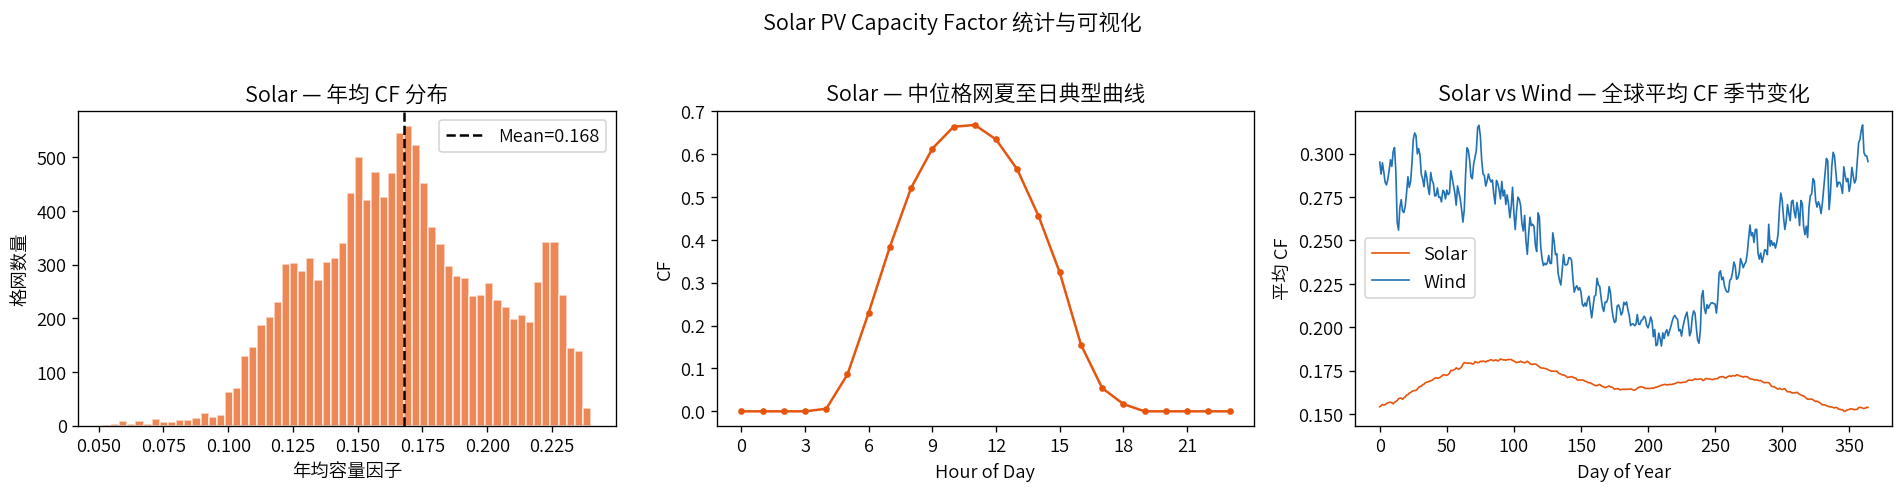

In [6]:
def load_mat_cfs(filepath, varname):
    mat = scipy.io.loadmat(filepath)
    data = mat[varname].astype(np.float32)
    # MATLAB 代码: res_CF = res_CF/10/1000 → 还原原始 CF
    data = data / 10 / 1000
    return data


solar_cfs = load_mat_cfs(
    os.path.join(DATA_DIR, 'Global_Solar_CFs.mat'), 'res_CF',
)

print(f"\n{'='*55}")
print(f"  Global_Solar_CFs.mat  [光伏容量因子]")
print(f"{'='*55}")
print(f"  Shape           : {solar_cfs.shape}  (格网数 × 8760h)")
print(f"  CF 范围         : [{solar_cfs.min():.4f}, {solar_cfs.max():.4f}]")
print(f"  全域均值 CF     : {solar_cfs.mean():.4f}")
annual_cf_solar = solar_cfs.mean(axis=1)
print(f"  年均 CF 最小: {annual_cf_solar.min():.4f}  最大: {annual_cf_solar.max():.4f}  均值: {annual_cf_solar.mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 年均 CF 直方图
axes[0].hist(annual_cf_solar, bins=60, color='#e6550d', alpha=0.7, edgecolor='white')
axes[0].axvline(annual_cf_solar.mean(), color='k', ls='--', lw=1.5,
                label=f'Mean={annual_cf_solar.mean():.3f}')
axes[0].set_title('Solar — 年均 CF 分布')
axes[0].set_xlabel('年均容量因子')
axes[0].set_ylabel('格网数量')
axes[0].legend()

# 典型日（夏至附近，第172天）的 24h 曲线
day172_start = 172 * 24
med_s_idx = np.argsort(annual_cf_solar)[len(annual_cf_solar)//2]
axes[1].plot(solar_cfs[med_s_idx, day172_start:day172_start+24],
             color='#e6550d', lw=1.5, marker='o', ms=3)
axes[1].set_title('Solar — 中位格网夏至日典型曲线')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('CF')
axes[1].set_xticks(range(0, 24, 3))

# 风光 CF 对比：全年日均曲线
daily_solar = solar_cfs.mean(axis=0).reshape(365, 24).mean(axis=1)
daily_wind2 = wind_cfs.mean(axis=0).reshape(365, 24).mean(axis=1)
axes[2].plot(daily_solar, color='#e6550d', lw=1, label='Solar')
axes[2].plot(daily_wind2,  color='#2171b5', lw=1, label='Wind')
axes[2].set_title('Solar vs Wind — 全球平均 CF 季节变化')
axes[2].set_xlabel('Day of Year')
axes[2].set_ylabel('平均 CF')
axes[2].legend()

plt.suptitle('Solar PV Capacity Factor 统计与可视化', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — 电力负荷数据 (`Global_Load_22region.mat`)

**含义**：20 个区域 × 8760 小时的逐时电力需求（SSP1-2.6 情景下，IIASA GDP/人口驱动 + 正弦函数叠加模型预测的 2050s 负荷），全球总量归一化至 IEA NZE 情景的 71,164 TWh/年


  Global_Load_22region.mat  [区域电力需求]
  Shape           : (20, 8760)  (20 区域 × 8760h)
  全球峰值负荷    : 13.591 TW
  全球年总需求    : 97238.1 TWh/年 → 97238.1 TW·h

  各区域年均负荷 (TW):
     1. Northern America    : 0.8989 TW  (年均: 7874.6 TWh)
     2. Caribbean           : 0.2438 TW  (年均: 2135.3 TWh)
     3. Central America     : 0.1124 TW  (年均: 984.9 TWh)
     4. Southern America    : 0.7242 TW  (年均: 6344.0 TWh)
     5. Northern Europe     : 0.2135 TW  (年均: 1870.6 TWh)
     6. Western Europe      : 0.3108 TW  (年均: 2722.3 TWh)
     7. Southern Europe     : 0.1605 TW  (年均: 1406.2 TWh)
     8. Eastern Europe      : 0.3401 TW  (年均: 2979.3 TWh)
     9. Central Asia        : 0.1124 TW  (年均: 984.8 TWh)
    10. Eastern Asia        : 2.1410 TW  (年均: 18755.5 TWh)
    11. Southern Asia       : 0.4588 TW  (年均: 4019.2 TWh)
    12. Southeastern Asia   : 2.3421 TW  (年均: 20517.1 TWh)
    13. Western Asia        : 0.7980 TW  (年均: 6990.5 TWh)
    14. Australia-NZ        : 0.0134 TW  (年均: 117.6 TWh)
    15. Melanesia  

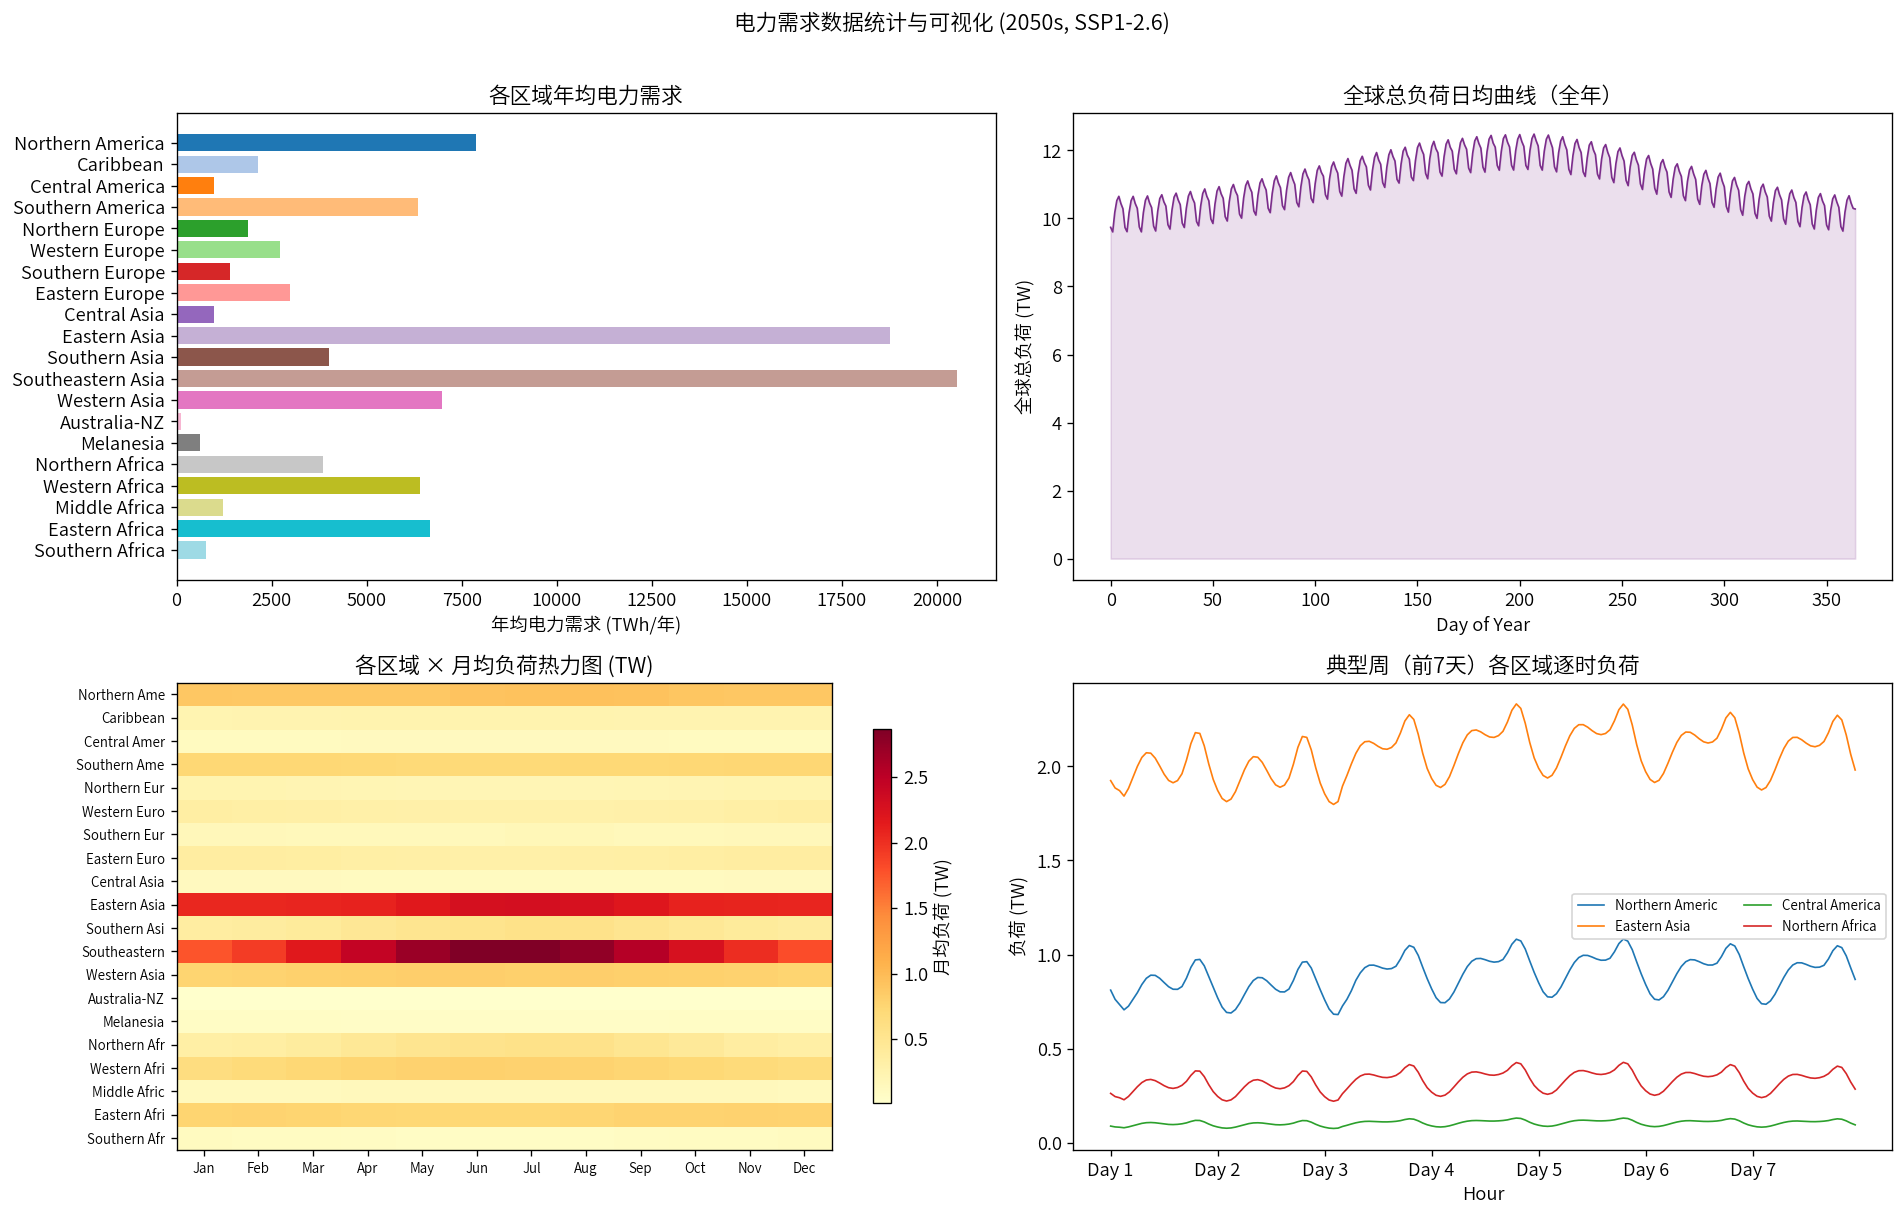

In [7]:
def load_loads(filepath, varname='all_loads'):
    mat = scipy.io.loadmat(filepath)
    data = mat[varname]  # shape: (phases, regions, 8760) or similar
    # 取第4个切片 (index 3) = 2050s，与 MATLAB 代码一致
    if data.ndim == 3:
        loads = data[3, :, :].astype(np.float64) / 1e6  # GW → TW
    else:
        loads = data.astype(np.float64) / 1e6
    return loads


loads = load_loads(
    os.path.join(DATA_DIR, 'Global_Load_22region.mat')
)

print(f"\n{'='*55}")
print(f"  Global_Load_22region.mat  [区域电力需求]")
print(f"{'='*55}")
print(f"  Shape           : {loads.shape}  (20 区域 × 8760h)")
print(f"  全球峰值负荷    : {loads.sum(axis=0).max():.3f} TW")
print(f"  全球年总需求    : {loads.sum()*8760/8760:.1f} TWh/年 → {loads.sum():.1f} TW·h")
print(f"\n  各区域年均负荷 (TW):")
for i, (name, val) in enumerate(zip(REGION_NAMES, loads.mean(axis=1))):
    print(f"    {i+1:2d}. {name:<20s}: {val:.4f} TW  "
          f"(年均: {val*8760:.1f} TWh)")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 各区域年均负荷条形图
ax = axes[0, 0]
colors = plt.cm.tab20(np.linspace(0, 1, 20))
bars = ax.barh(REGION_NAMES, loads.mean(axis=1)*8760, color=colors)
ax.set_xlabel('年均电力需求 (TWh/年)')
ax.set_title('各区域年均电力需求')
ax.invert_yaxis()

# 2. 全球总负荷：日均时间序列（全年）
ax = axes[0, 1]
global_load = loads.sum(axis=0)
daily_gl = global_load.reshape(365, 24).mean(axis=1)
ax.plot(daily_gl, color='#7b2d8b', lw=1)
ax.fill_between(range(365), daily_gl, alpha=0.15, color='#7b2d8b')
ax.set_title('全球总负荷日均曲线（全年）')
ax.set_xlabel('Day of Year')
ax.set_ylabel('全球总负荷 (TW)')

# 3. 各区域 × 月均负荷热力图
ax = axes[1, 0]
monthly_loads = []
days_in_month = [31,28,31,30,31,30,31,31,30,31,30,31]
start = 0
for dm in days_in_month:
    end = start + dm * 24
    monthly_loads.append(loads[:, start:end].mean(axis=1))
    start = end
monthly_loads = np.array(monthly_loads).T  # (20, 12)
im = ax.imshow(monthly_loads, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, shrink=0.8, label='月均负荷 (TW)')
ax.set_yticks(range(20))
ax.set_yticklabels([n[:12] for n in REGION_NAMES], fontsize=8)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax.set_title('各区域 × 月均负荷热力图 (TW)')

# 4. 典型周的区域负荷曲线（前 7 天，选 4 个大区）
ax = axes[1, 1]
highlight = [0, 9, 2, 15]  # N.America, E.Asia, C.America, N.Africa
for idx in highlight:
    ax.plot(loads[idx, :168], lw=1, label=REGION_NAMES[idx][:15])
ax.set_title('典型周（前7天）各区域逐时负荷')
ax.set_xlabel('Hour')
ax.set_ylabel('负荷 (TW)')
ax.set_xticks(np.arange(0, 168, 24))
ax.set_xticklabels([f'Day {d+1}' for d in range(7)])
ax.legend(fontsize=8, ncol=2)

plt.suptitle('电力需求数据统计与可视化 (2050s, SSP1-2.6)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 6 — 系统初始状态与互联结构 (`Global_Init_State.mat` & `Global_Trans.mat`)

**含义**：现有装机（`cur_solar`, `cur_wind`, `cur_storage`）作为非线性约束下界；互联拓扑矩阵（S-G 全球互联）和输电损耗矩阵


  Global_Init_State  [现有装机/互联状态]
  cur_solar shape  : (20,)
  cur_wind  shape  : (20,)
  cur_trans shape  : (20, 20)

  各区域现有装机 (GW):
  区域                         Solar      Wind   Storage
  --------------------------------------------------
  Northern America        143609.0  164968.0   19107.6
  Caribbean                12825.0    8644.0       6.0
  Central America          13406.0   10857.0       0.0
  Southern America         49076.0   39785.0     974.0
  Northern Europe          27172.0   54849.0    3652.0
  Western Europe          147453.0   76528.0   10329.7
  Southern Europe          71890.0   44928.8    8584.0
  Eastern Europe           40239.0   18449.0    7661.0
  Central Asia              1555.5    1440.8       0.0
  Eastern Asia            734202.0  288772.4   80139.1
  Southern Asia            29577.0   13440.0     540.0
  Southeastern Asia        74017.0   47215.0    5825.6
  Western Asia             25748.0    6902.0    1296.0
  Australia-NZ               324.4      72

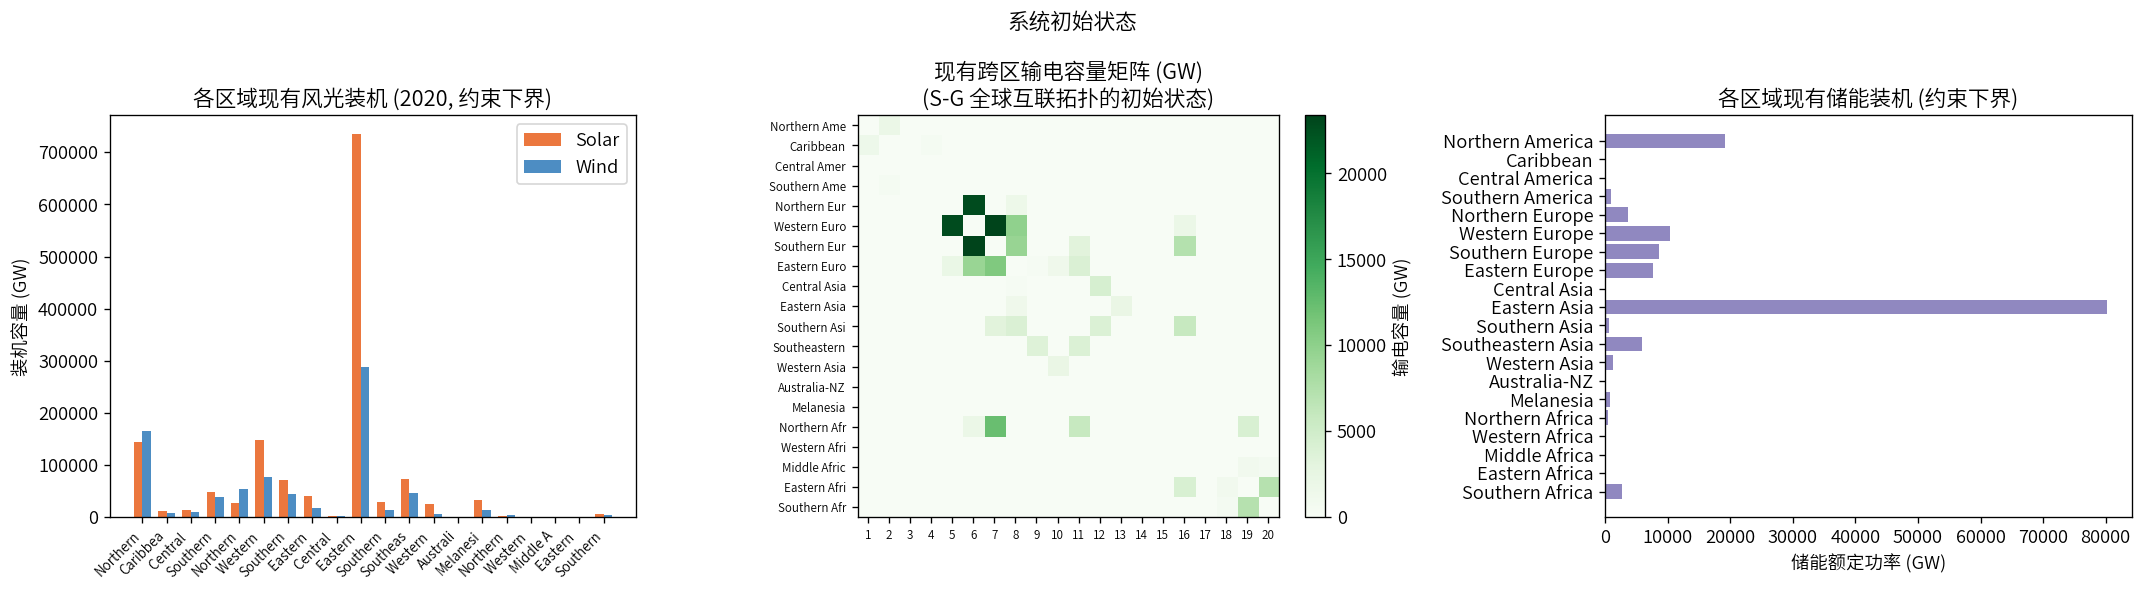

In [8]:
def load_init_state(filepath):
    mat = scipy.io.loadmat(filepath)
    cur_solar   = mat['cur_solar'].ravel().astype(np.float64)
    cur_wind    = mat['cur_wind'].ravel().astype(np.float64)
    cur_storage = mat['cur_storage'].ravel().astype(np.float64)
    cur_trans   = mat['cur_trans'].astype(np.float64)
    return cur_solar, cur_wind, cur_storage, cur_trans


cur_solar, cur_wind, cur_storage, cur_trans = load_init_state(
    os.path.join(DATA_DIR, 'Global_Init_State.mat')
)

print(f"\n{'='*55}")
print(f"  Global_Init_State  [现有装机/互联状态]")
print(f"{'='*55}")
print(f"  cur_solar shape  : {cur_solar.shape}")
print(f"  cur_wind  shape  : {cur_wind.shape}")
print(f"  cur_trans shape  : {cur_trans.shape}")
print(f"\n  各区域现有装机 (GW):")
header = f"  {'区域':<22}  {'Solar':>8}  {'Wind':>8}  {'Storage':>8}"
print(header)
print('  ' + '-'*50)
for i, name in enumerate(REGION_NAMES):
    print(f"  {name:<22}  {cur_solar[i]:8.1f}  {cur_wind[i]:8.1f}  {cur_storage[i]:8.1f}")
print(f"\n  全球合计: Solar={cur_solar.sum():.0f} GW, Wind={cur_wind.sum():.0f} GW")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 各区域现有装机条形图
x = np.arange(20)
width = 0.35
axes[0].bar(x - width/2, cur_solar, width, label='Solar', color='#e6550d', alpha=0.8)
axes[0].bar(x + width/2, cur_wind,  width, label='Wind',  color='#2171b5', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n[:8] for n in REGION_NAMES], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('装机容量 (GW)')
axes[0].set_title('各区域现有风光装机 (2020, 约束下界)')
axes[0].legend()

# 2. 现有跨区输电容量矩阵（热力图）
im2 = axes[1].imshow(cur_trans, cmap='Greens', aspect='auto')
plt.colorbar(im2, ax=axes[1], label='输电容量 (GW)')
axes[1].set_xticks(range(20))
axes[1].set_yticks(range(20))
axes[1].set_xticklabels([str(i+1) for i in range(20)], fontsize=7)
axes[1].set_yticklabels([n[:12] for n in REGION_NAMES], fontsize=7)
axes[1].set_title('现有跨区输电容量矩阵 (GW)\n(S-G 全球互联拓扑的初始状态)')

# 3. 现有储能容量
axes[2].barh(REGION_NAMES, cur_storage, color='#756bb1', alpha=0.8)
axes[2].set_xlabel('储能额定功率 (GW)')
axes[2].set_title('各区域现有储能装机 (约束下界)')
axes[2].invert_yaxis()

plt.suptitle('系统初始状态', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 7 — 提取最优解 & 可视化场站位置

### 7.1 读取优化结果并分析帕累托前沿


  优化结果
  res_scale shape    : (70, 12783)  (帕累托解数 × 决策变量数)
  prs shape          : (70, 3)  (帕累托解数 × 3目标)

  帕累托前沿统计:
  f(1) 弃电率       : [0.0461, 0.2365]  均值=0.0865
  f(2) 1-渗透率     : [0.1051, 0.2380]  均值=0.1392
  f(3) 投资成本     : [86072.5, 167550.3] 万亿USD  均值=119853.3


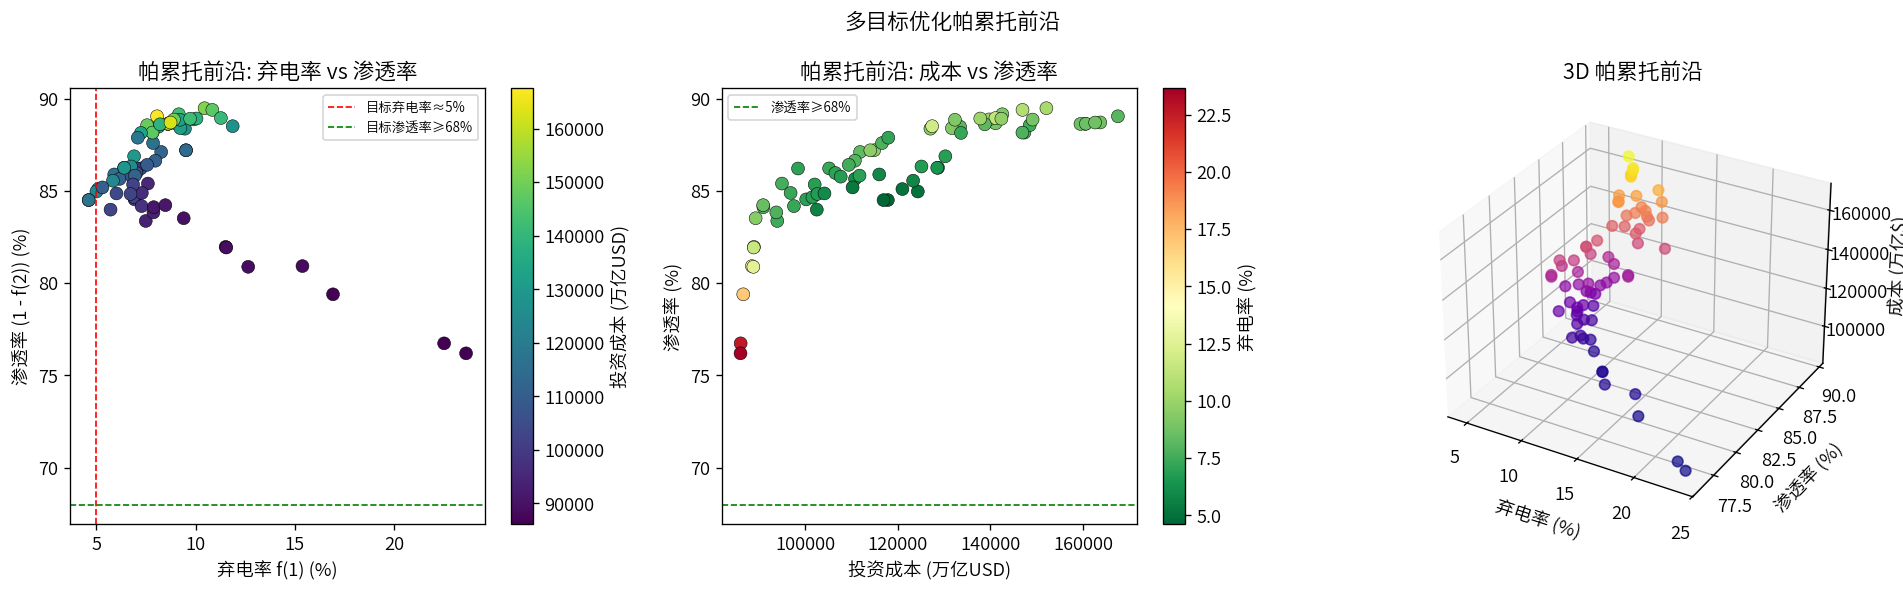

In [9]:
def load_results(result_file):
    with h5py.File(result_file, "r") as f:
        res_scale = f["/res_scale"][:]
        prs = f["/prs"][:]
    # MATLAB 保存的 HDF5 矩阵是列优先，Python 读出来行列互换
    # 确保 shape 为 (n_pareto, n_vars) 和 (n_pareto, 3)
    if res_scale.ndim == 2 and res_scale.shape[0] < res_scale.shape[1]:
        res_scale = res_scale  # (70, 12783)
    else:
        res_scale = res_scale.T  # (12783, 70) → (70, 12783)
    if prs.ndim == 2 and prs.shape[0] == 3:
        prs = prs.T  # (3, 70) → (70, 3)
    return res_scale, prs


res_scale, prs = load_results(RESULT_FILE)

print(f"\n{'='*55}")
print(f"  优化结果")
print(f"{'='*55}")
print(f"  res_scale shape    : {res_scale.shape}  (帕累托解数 × 决策变量数)")
print(f"  prs shape          : {prs.shape}  (帕累托解数 × 3目标)")
print(f"\n  帕累托前沿统计:")
print(f"  f(1) 弃电率       : [{prs[:,0].min():.4f}, {prs[:,0].max():.4f}]  均值={prs[:,0].mean():.4f}")
print(f"  f(2) 1-渗透率     : [{prs[:,1].min():.4f}, {prs[:,1].max():.4f}]  均值={prs[:,1].mean():.4f}")
print(f"  f(3) 投资成本     : [{prs[:,2].min():.1f}, {prs[:,2].max():.1f}] 万亿USD  均值={prs[:,2].mean():.1f}")

# 可视化帕累托前沿
fig = plt.figure(figsize=(16, 5))

# 2D: curtailment vs penetration
ax1 = fig.add_subplot(131)
sc1 = ax1.scatter(prs[:, 0] * 100, (1 - prs[:, 1]) * 100, c=prs[:, 2], cmap="viridis", s=60, edgecolors="k", lw=0.3)
plt.colorbar(sc1, ax=ax1, label="投资成本 (万亿USD)")
ax1.set_xlabel("弃电率 f(1) (%)")
ax1.set_ylabel("渗透率 (1 - f(2)) (%)")
ax1.set_title("帕累托前沿: 弃电率 vs 渗透率")
ax1.axvline(5, color="r", ls="--", lw=1, label="目标弃电率≈5%")
ax1.axhline(68, color="g", ls="--", lw=1, label="目标渗透率≥68%")
ax1.legend(fontsize=8)

# 2D: cost vs penetration
ax2 = fig.add_subplot(132)
sc2 = ax2.scatter(prs[:, 2], (1 - prs[:, 1]) * 100, c=prs[:, 0] * 100, cmap="RdYlGn_r", s=60, edgecolors="k", lw=0.3)
plt.colorbar(sc2, ax=ax2, label="弃电率 (%)")
ax2.set_xlabel("投资成本 (万亿USD)")
ax2.set_ylabel("渗透率 (%)")
ax2.set_title("帕累托前沿: 成本 vs 渗透率")
ax2.axhline(68, color="g", ls="--", lw=1, label="渗透率≥68%")
ax2.legend(fontsize=8)

# 3D 帕累托前沿
ax3 = fig.add_subplot(133, projection="3d")
sc3 = ax3.scatter(prs[:, 0] * 100, (1 - prs[:, 1]) * 100, prs[:, 2], c=prs[:, 2], cmap="plasma", s=40, alpha=0.7)
ax3.set_xlabel("弃电率 (%)", labelpad=6)
ax3.set_ylabel("渗透率 (%)", labelpad=6)
ax3.set_zlabel("成本 (万亿$)", labelpad=6)
ax3.set_title("3D 帕累托前沿")

plt.suptitle("多目标优化帕累托前沿", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
with h5py.File(RESULT_FILE, 'r') as f:
    print("文件中所有 key：", list(f.keys()))
    for k in f.keys():
        print(f"  {k}: shape={f[k].shape}, dtype={f[k].dtype}")

文件中所有 key： ['prs', 'res_scale']
  prs: shape=(3, 70), dtype=float64
  res_scale: shape=(12783, 70), dtype=float64


### 7.2 按论文标准筛选最优解

**筛选条件**（来自论文方法）：渗透率 ≥ 68%（即 f(2) ≤ 0.32），弃电率 ≈ 5%（f(1) ≤ 0.06），在满足条件的解中取**投资成本最小**者

In [11]:
def get_solar_candidates(data_dir):
    """
    获取光伏候选格网的候选数、索引和经纬度坐标。

    筛选逻辑 (与 MATLAB CompletingPrices.m 一致):
      1. Global_fishnet.tif 值 < 65536 → 有效格网
      2. 光伏装机容量 > 0.001 TWp (= 1 GWp)
      3. 年发电量 < 10 TWh

    使用 ravel(order='F') 匹配 MATLAB 的 column-major find() 索引，
    确保 ins 和 cf_sum 来自同一格网。

    Returns: (n_cand, lons, lats)
    """
    # 1. 有效格网 (column-major, 匹配 MATLAB find)
    with rasterio.open(os.path.join(data_dir, 'Global_fishnet.tif')) as src:
        grids = src.read(1).astype(np.float64)
        nrows, ncols = grids.shape
        tif_transform = src.transform

    solar_all_idx = np.where(grids.ravel(order='F') < 65536)[0]

    # 2. 面积数据 (column-major flatten)
    with rasterio.open(os.path.join(data_dir, 'Global_Solar_Net_Area_Add_Egrid.tif')) as src:
        luccs = src.read(1).astype(np.float64).ravel(order='F') / 100.0
    with rasterio.open(os.path.join(data_dir, 'Global_Solar_Fishnet_Area.tif')) as src:
        fish_area = src.read(1).astype(np.float64).ravel(order='F')
    fish_area[fish_area < 0] = 0

    # 3. 装机容量 (column-major 索引，与 CF 行对齐)
    areas = luccs[solar_all_idx] * fish_area[solar_all_idx]
    solar_ins = 74 * areas / 1e6  # TWp

    # 4. CF — res_CF 行顺序 = MATLAB find() 的 column-major 顺序
    mat = scipy.io.loadmat(os.path.join(data_dir, 'Global_Solar_CFs.mat'))
    res_CF = mat['res_CF'].astype(np.float64) / 10 / 1000
    cf_sum = res_CF.sum(axis=1)
    del res_CF, mat

    # 5. 年发电量 (TWh) = ins(TWp) × sum(CF)
    annual_gen = solar_ins * cf_sum

    # 6. 筛选
    keep = (solar_ins > 0.001) & (annual_gen < 10)
    solar_index2 = solar_all_idx[keep]
    n_cand = len(solar_index2)

    # 7. 转换为经纬度
    rows, cols = np.unravel_index(solar_index2, (nrows, ncols), order='F')
    lons = tif_transform.c + (cols + 0.5) * tif_transform.a
    lats = tif_transform.f + (rows + 0.5) * tif_transform.e

    print(f"  光伏: 有效格网 {len(solar_ins)}, "
          f"ins>0.001 → {(solar_ins > 0.001).sum()}, "
          f"+ gen<10 → {n_cand}")
    return n_cand, lons, lats


def get_wind_candidates(data_dir):
    """
    获取风电候选格网的候选数、索引和经纬度坐标。

    筛选逻辑 (与 MATLAB CompletingPrices.m 一致):
      1. 风电净面积占比 > 0
      2. 风电装机容量 > 0.0001 TWp (= 0.1 GWp)
      3. 年发电量 < 10 TWh

    使用 ravel(order='F') 匹配 MATLAB column-major 索引。
    陆地格网安装密度 4.6 MW/km², 其余 2.7 MW/km²

    Returns: (n_cand, lons, lats)
    """
    # 1. 有效格网 (column-major)
    with rasterio.open(os.path.join(data_dir, 'Global_Wind_Net_Area_Add_Egrid.tif')) as src:
        luccs_2d = src.read(1).astype(np.float64)
        nrows, ncols = luccs_2d.shape
        tif_transform = src.transform
    luccs = luccs_2d.ravel(order='F') / 100.0
    wind_all_idx = np.where(luccs > 0)[0]

    # 2. 面积数据 (column-major)
    with rasterio.open(os.path.join(data_dir, 'Global_Wind_Fishnet_Area.tif')) as src:
        fish_area = src.read(1).astype(np.float64).ravel(order='F')

    # 3. 陆地掩膜 (column-major)
    with rasterio.open(os.path.join(data_dir, 'Global_LandMask.tif')) as src:
        lm = src.read(1).astype(np.float64).ravel(order='F')
    lm[lm < 100] = 0
    lm[lm > 100] = 1

    # 4. 装机容量
    areas = luccs[wind_all_idx] * fish_area[wind_all_idx]
    lm_sel = lm[wind_all_idx]
    wind_ins = 2.7 * areas / 1e6  # TWp (默认)
    wind_ins[lm_sel == 1] = 4.6 * areas[lm_sel == 1] / 1e6  # 陆地

    # 5. CF — H5 行顺序 = MATLAB find() 的 column-major 顺序
    with h5py.File(os.path.join(data_dir, 'Global_Wind_CFs_Sel.h5'), 'r') as f:
        wind_cfs = f['/data'][:].astype(np.float64)
    if wind_cfs.shape[0] == 8760 and wind_cfs.shape[1] != 8760:
        wind_cfs = wind_cfs.T
    cf_sum = wind_cfs.sum(axis=1)
    del wind_cfs

    # 6. 年发电量
    annual_gen = wind_ins * cf_sum

    # 7. 筛选
    keep = (wind_ins > 0.0001) & (annual_gen < 10)
    win_index2 = wind_all_idx[keep]
    n_cand = len(win_index2)

    # 8. 转换为经纬度
    rows, cols = np.unravel_index(win_index2, (nrows, ncols), order='F')
    lons = tif_transform.c + (cols + 0.5) * tif_transform.a
    lats = tif_transform.f + (rows + 0.5) * tif_transform.e

    print(f"  风电: 有效格网 {len(wind_ins)}, "
          f"ins>0.0001 → {(wind_ins > 0.0001).sum()}, "
          f"+ gen<10 → {n_cand}")
    return n_cand, lons, lats


# ── 调用 ──
n_solar_cand, solar_lons, solar_lats = get_solar_candidates(DATA_DIR)
n_wind_cand, wind_lons, wind_lats = get_wind_candidates(DATA_DIR)
print(f"\n  n_solar_cand = {n_solar_cand}")
print(f"  n_wind_cand  = {n_wind_cand}")
print(f"  候选格网合计  = {n_solar_cand + n_wind_cand}")
print(f"  res_scale 列长 = {res_scale.shape[1]}  (候选 + 储能40 + 输电)")

  光伏: 有效格网 13296, ins>0.001 → 7649, + gen<10 → 2166
  风电: 有效格网 8477, ins>0.0001 → 6778, + gen<10 → 6743

  n_solar_cand = 2166
  n_wind_cand  = 6743
  候选格网合计  = 8909
  res_scale 列长 = 12783  (候选 + 储能40 + 输电)


In [12]:
# ── 筛选条件 ──────────────────────────────────────
PENETRATION_MIN = 0.68  # 渗透率下限
CURTAILMENT_MAX = 0.06  # 弃电率上限（~5%，略放宽到6%）
# ──────────────────────────────────────────────────

cr_ok = prs[:, 0] <= CURTAILMENT_MAX
pen_ok = prs[:, 1] <= (1 - PENETRATION_MIN)
feasible_mask = cr_ok & pen_ok
feasible_idx = np.where(feasible_mask)[0]

print(f"满足渗透率≥{PENETRATION_MIN*100:.0f}% 且 弃电率≤{CURTAILMENT_MAX*100:.0f}% 的解数量: {len(feasible_idx)}")

if len(feasible_idx) == 0:
    print("\n  ★ 未找到满足双重约束的解，放宽条件（仅要求渗透率≥68%）")
    feasible_idx = np.where(prs[:, 1] <= (1 - PENETRATION_MIN))[0]
    print(f"  放宽后满足的解数量: {len(feasible_idx)}")

# 在可行解中，选投资成本最小的
best_local = np.argmin(prs[feasible_idx, 2])
best_idx = feasible_idx[best_local]

best_cr = prs[best_idx, 0]
best_pen = 1 - prs[best_idx, 1]
best_cost = prs[best_idx, 2]
best_sol = res_scale[best_idx, :] # len(best_sol) = 12783

print(f"\n{'='*55}")
print(f"  最优解 (第 {best_idx} 个帕累托解)")
print(f"{'='*55}")
print(f"  弃电率          : {best_cr*100:.2f}%")
print(f"  渗透率          : {best_pen*100:.2f}%")
print(f"  总投资          : {best_cost:.1f} 万亿 USD")

# 从决策变量中解析场站、储能、输电
n_cand_total = n_solar_cand + n_wind_cand
selection = np.round(best_sol[:n_cand_total]).astype(int)
solar_sel = selection[:n_solar_cand]
wind_sel = selection[n_solar_cand:]

storage_pow = best_sol[n_cand_total : n_cand_total + 20]
storage_dur = best_sol[n_cand_total + 20 : n_cand_total + 40]
trans_cap = best_sol[n_cand_total + 40 :]

print(f"\n  选中光伏格网数  : {solar_sel.sum():,} / {n_solar_cand:,} " f"({solar_sel.mean()*100:.1f}%)")
print(f"  选中风电格网数  : {wind_sel.sum():,} / {n_wind_cand:,} " f"({wind_sel.mean()*100:.1f}%)")
print(f"\n  各区域储能功率 (GW):")
for i, (name, sp, sd) in enumerate(zip(REGION_NAMES, storage_pow, storage_dur)):
    cap_gwh = sp * sd
    print(f"    {name:<22}: {sp:.0f} GW × {sd:.0f}h = {cap_gwh:.0f} GWh")
print(f"\n  输电走廊容量 (GW): 均值={trans_cap.mean():.0f}  最大={trans_cap.max():.0f}")

满足渗透率≥68% 且 弃电率≤6% 的解数量: 8

  最优解 (第 0 个帕累托解)
  弃电率          : 5.71%
  渗透率          : 83.99%
  总投资          : 102541.8 万亿 USD

  选中光伏格网数  : 1,088 / 2,166 (50.2%)
  选中风电格网数  : 3,240 / 6,743 (48.0%)

  各区域储能功率 (GW):
    Northern America      : 0 GW × 0h = 0 GWh
    Caribbean             : 1 GW × 0h = 0 GWh
    Central America       : 1 GW × 0h = 0 GWh
    Southern America      : 1 GW × 0h = 0 GWh
    Northern Europe       : 1 GW × 0h = 0 GWh
    Western Europe        : 0 GW × 1h = 0 GWh
    Southern Europe       : 0 GW × 1h = 0 GWh
    Eastern Europe        : 0 GW × 0h = 0 GWh
    Central Asia          : 0 GW × 1h = 0 GWh
    Eastern Asia          : 1 GW × 1h = 1 GWh
    Southern Asia         : 1 GW × 1h = 1 GWh
    Southeastern Asia     : 0 GW × 1h = 0 GWh
    Western Asia          : 0 GW × 0h = 0 GWh
    Australia-NZ          : 0 GW × 0h = 0 GWh
    Melanesia             : 0 GW × 0h = 0 GWh
    Northern Africa       : 1 GW × 0h = 0 GWh
    Western Africa        : 1 GW × 1h = 1 GWh
    

### 7.3 可视化最优解场站位置

  选中光伏: 1,088 / 2,166
  选中风电: 3,240 / 6,743


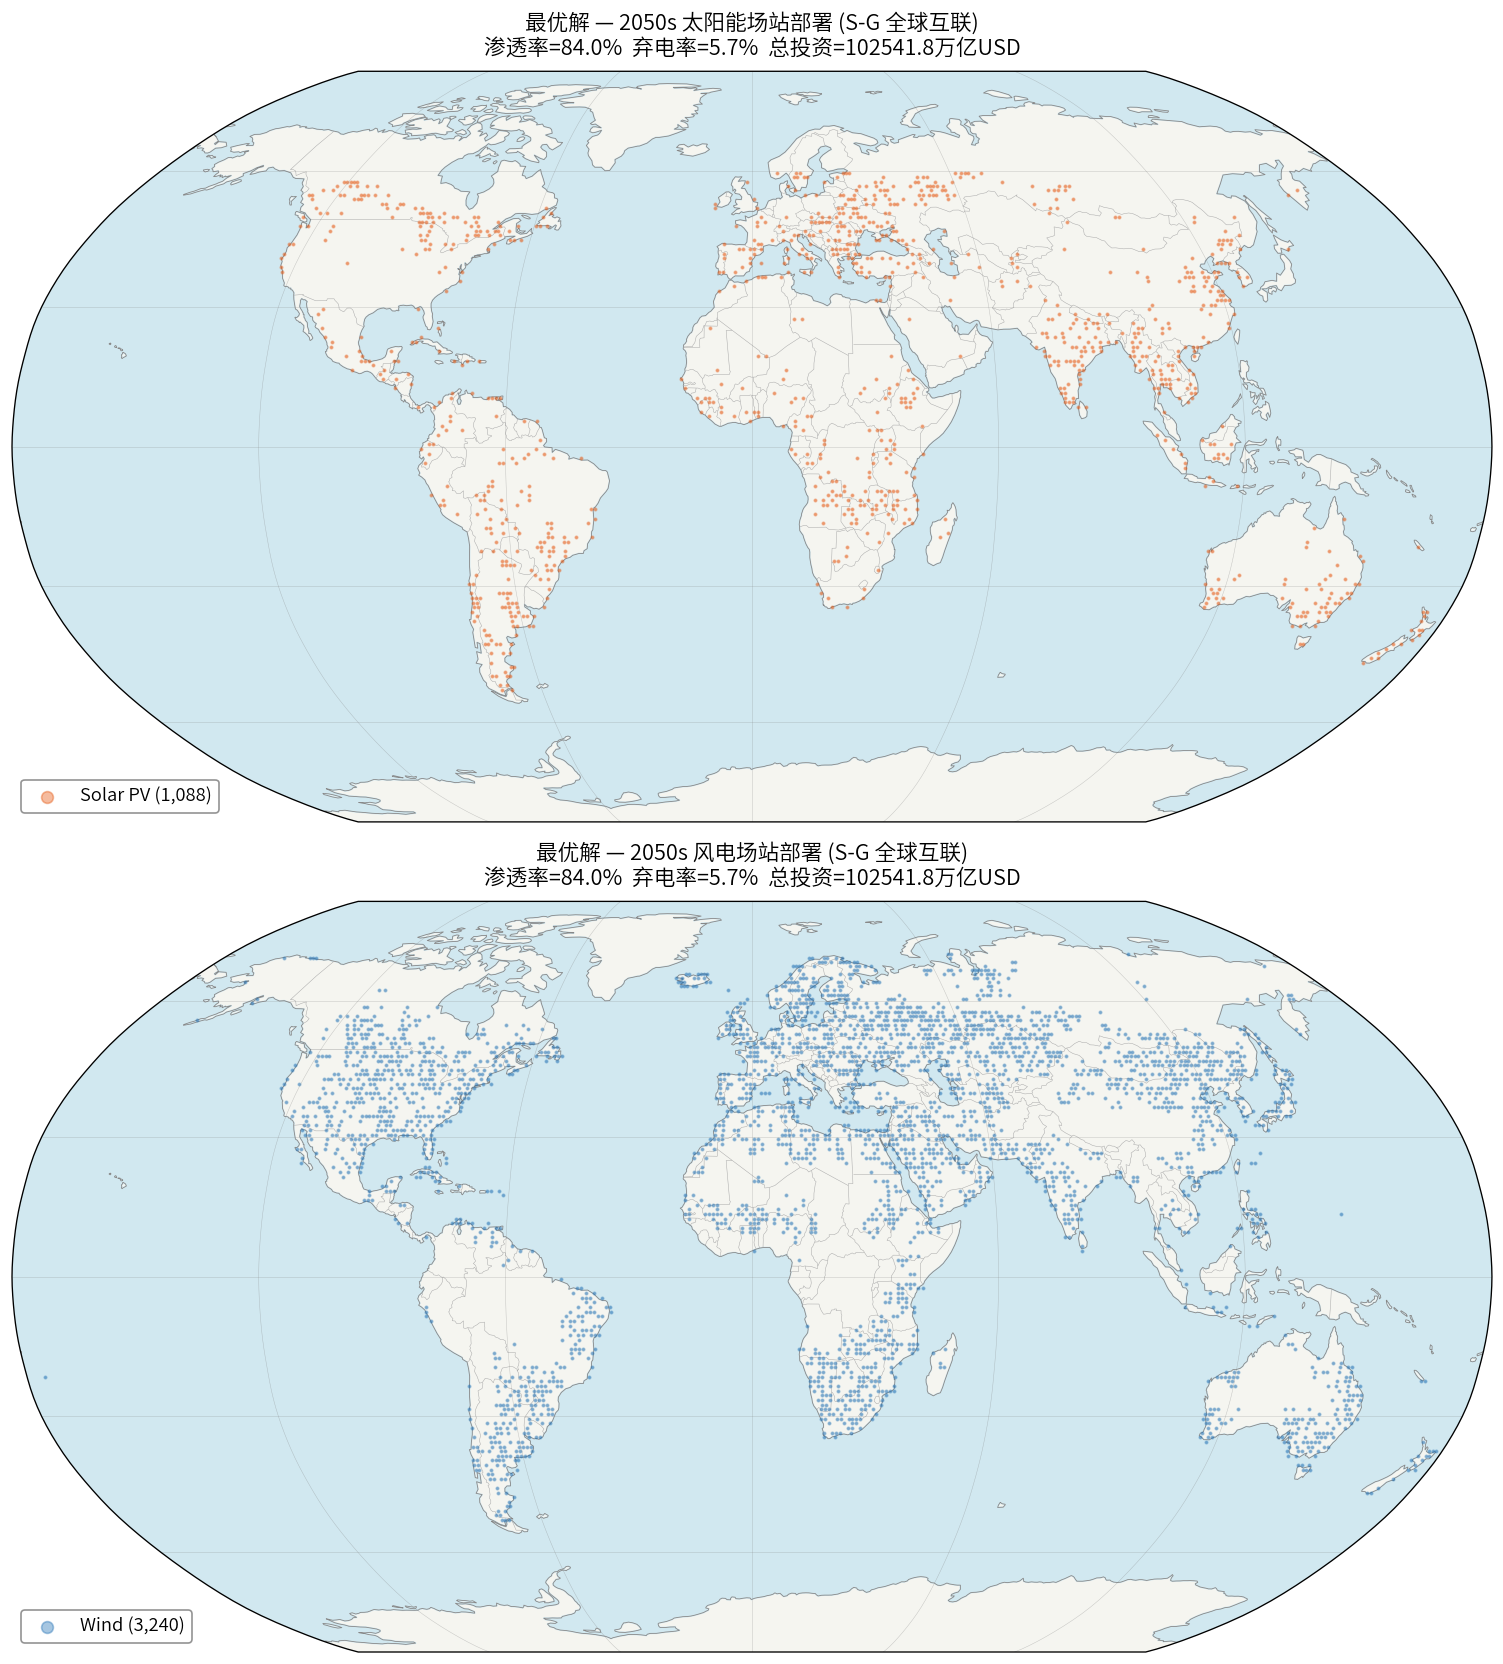

In [13]:
# ── 7.3 可视化最优解场站位置 ──
#
# 候选格网坐标由上一 cell 的 get_solar_candidates / get_wind_candidates 计算，
# n_solar_cand / n_wind_cand / solar_lons / solar_lats / wind_lons / wind_lats 已就绪。

sel_slon = solar_lons[solar_sel == 1]
sel_slat = solar_lats[solar_sel == 1]
sel_wlon = wind_lons[wind_sel == 1]
sel_wlat = wind_lats[wind_sel == 1]

print(f"  选中光伏: {len(sel_slon):,} / {n_solar_cand:,}")
print(f"  选中风电: {len(sel_wlon):,} / {n_wind_cand:,}")
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(16, 14),
    subplot_kw={"projection": ccrs.Robinson()},
)

def setup_basemap(ax):
    ax.set_global()
    ax.add_feature(cfeature.LAND,      color="#f5f5f0", zorder=0)
    ax.add_feature(cfeature.OCEAN,     color="#d1e8f0", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="#888", zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, color="#aaa", zorder=1)
    ax.gridlines(linewidth=0.3, color="gray", alpha=0.4)

# ── 上图：太阳能 PV ──────────────────────────────────────────────
setup_basemap(ax1)
ax1.scatter(
    sel_slon, sel_slat,
    s=2, c="#e6550d", alpha=0.4,
    transform=ccrs.PlateCarree(),
    label=f"Solar PV ({solar_sel.sum():,})",
    rasterized=True,
)
ax1.legend(loc="lower left", fontsize=11, markerscale=5,
           framealpha=0.9, edgecolor="#888")
ax1.set_title(
    f"最优解 — 2050s 太阳能场站部署 (S-G 全球互联)\n"
    f"渗透率={best_pen*100:.1f}%  弃电率={best_cr*100:.1f}%  "
    f"总投资={best_cost:.1f}万亿USD",
    fontsize=13, pad=10,
)

# ── 下图：风电 ──────────────────────────────────────────────────
setup_basemap(ax2)
ax2.scatter(
    sel_wlon, sel_wlat,
    s=2, c="#2171b5", alpha=0.4,
    transform=ccrs.PlateCarree(),
    label=f"Wind ({wind_sel.sum():,})",
    rasterized=True,
)
ax2.legend(loc="lower left", fontsize=11, markerscale=5,
           framealpha=0.9, edgecolor="#888")
ax2.set_title(
    f"最优解 — 2050s 风电场站部署 (S-G 全球互联)\n"
    f"渗透率={best_pen*100:.1f}%  弃电率={best_cr*100:.1f}%  "
    f"总投资={best_cost:.1f}万亿USD",
    fontsize=13, pad=10,
)

plt.tight_layout()
plt.show()

### 7.4 各区域装机汇总 & 储能/输电可视化

### 8 2030、2040、2050 年的最优解可视化

SA_2030 候选: 光伏=2334  风电=2312
SC_2040 候选: 光伏=4324  风电=4294
SG_2050 候选: 光伏=2166  风电=6743
  2030: 光伏选中 1,146/2,334  风电选中 1,340/2,312  弃电率=12.1%  渗透率=81.9%
  2040: 光伏选中 2,280/4,324  风电选中 2,313/4,294  弃电率=2.1%  渗透率=73.0%
  2050: 光伏选中 1,145/2,166  风电选中 3,325/6,743  弃电率=7.0%  渗透率=86.2%


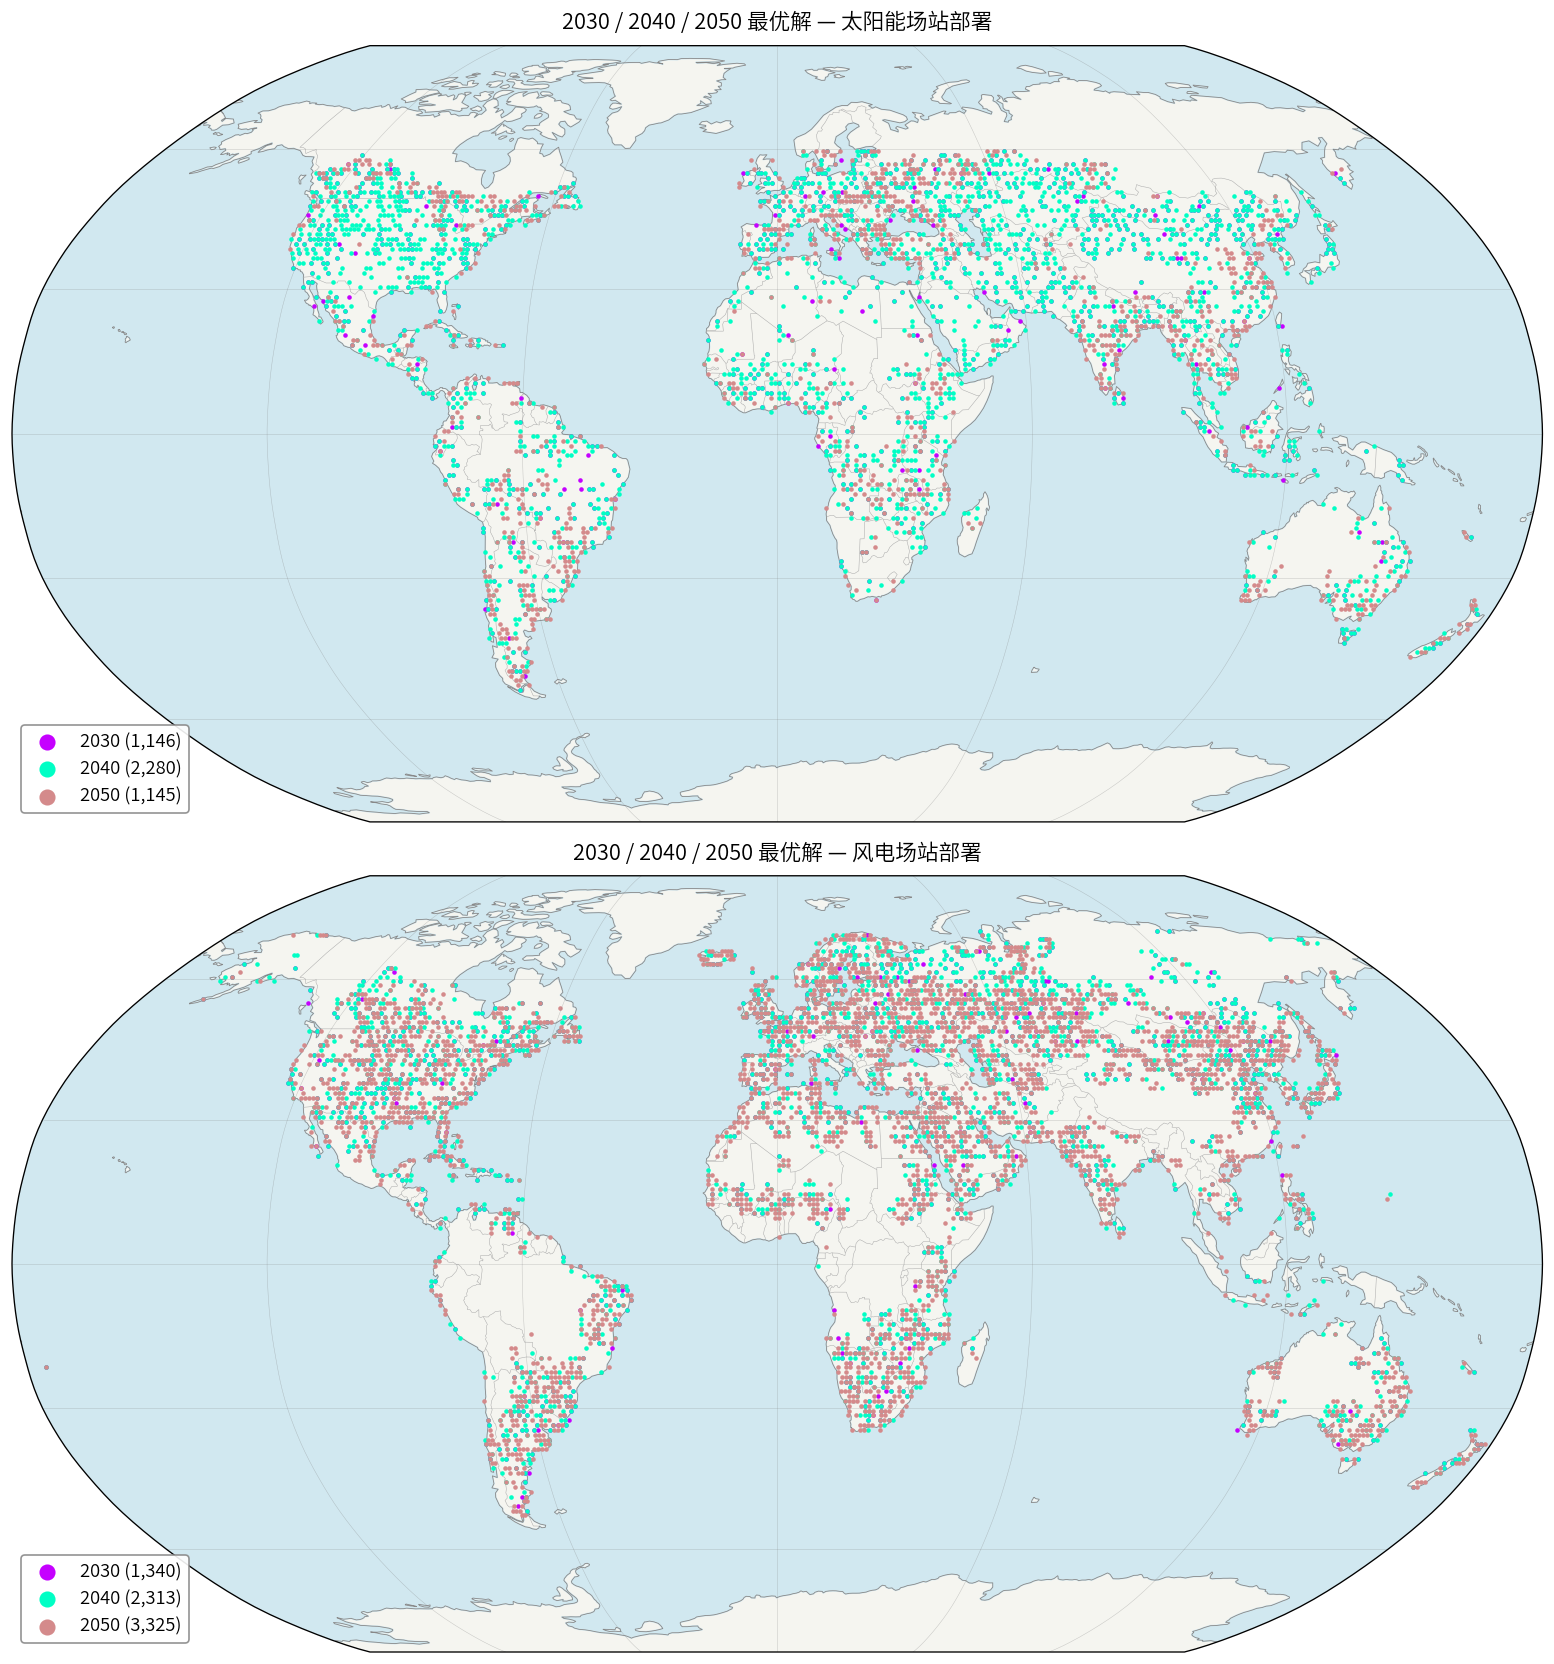

In [ ]:
# ── Section 8: 2030、2040、2050 年最优解场站位置可视化 ──
# 复用: load_results, setup_basemap, n_solar_cand / solar_lons / ... (from §7)

file_2030_result = "Resilience/Optimization_SA_2030_Res.h5"
file_2040_result = "Resilience/Optimization_SC_2040_Res.h5"
file_2050_result = "Resilience/Optimization_SG_2050_Res.h5"


# ── 从上层优化结果提取候选格网坐标 (column-major 顺序) ──
def get_scenario_candidates(opt_file):
    """从上层优化结果 .mat 文件中提取候选格网的经纬度坐标.

    嵌套逻辑: SA_2030 候选 = SC_2040 选中格网;
              SC_2040 候选 = SG_2050 选中格网.
    """
    mat = scipy.io.loadmat(opt_file)
    opt_solar = mat["opt_solar"]  # (180, 360)
    opt_wind = mat["opt_wind"]  # (180, 360)
    nrows = opt_solar.shape[0]  # 180

    # MATLAB find() → column-major; 用 ravel(order='F') 模拟
    sflat = np.nonzero(opt_solar.ravel(order="F"))[0]
    wflat = np.nonzero(opt_wind.ravel(order="F"))[0]

    srows, scols = sflat % nrows, sflat // nrows
    wrows, wcols = wflat % nrows, wflat // nrows

    slon, slat = -179.5 + scols, 89.5 - srows
    wlon, wlat = -179.5 + wcols, 89.5 - wrows

    return len(sflat), slon, slat, len(wflat), wlon, wlat


# SA_2030 候选 = SC_2040 选中的格网;  SC_2040 候选 = SG_2050 选中的格网
ns30, slon30, slat30, nw30, wlon30, wlat30 = get_scenario_candidates("Optimization/Opt_SC_2040_Sel.mat")
ns40, slon40, slat40, nw40, wlon40, wlat40 = get_scenario_candidates("Optimization/Opt_SG_2050_Sel.mat")
# SG_2050 使用 §7 已计算的候选坐标
ns50, slon50, slat50 = n_solar_cand, solar_lons, solar_lats
nw50, wlon50, wlat50 = n_wind_cand, wind_lons, wind_lats

print(f"SA_2030 候选: 光伏={ns30}  风电={nw30}")
print(f"SC_2040 候选: 光伏={ns40}  风电={nw40}")
print(f"SG_2050 候选: 光伏={ns50}  风电={nw50}")


# ── 加载结果 & 选择最优解 (归一化 knee-point) ──
def select_knee_solution(result_file):
    """加载结果，用归一化 knee-point 选最优解."""
    res, prs = load_results(result_file)
    # load_results 只对 3-objective 转置 prs; 修正 2-objective 情况
    if prs.shape[0] != res.shape[0]:
        prs = prs.T  # (n_obj, 70) → (70, n_obj)
    # 归一化到 [0, 1]
    pmin, pmax = prs.min(0), prs.max(0)
    prange = pmax - pmin
    prange[prange == 0] = 1
    prs_n = (prs - pmin) / prange
    # 距原点最近的解 = knee-point
    dist = np.sqrt((prs_n**2).sum(axis=1))
    best = np.argmin(dist)
    return res[best], prs[best]


scenarios = {
    2030: dict(file=file_2030_result, ns=ns30, nw=nw30, slon=slon30, slat=slat30, wlon=wlon30, wlat=wlat30),
    2040: dict(file=file_2040_result, ns=ns40, nw=nw40, slon=slon40, slat=slat40, wlon=wlon40, wlat=wlat40),
    2050: dict(file=file_2050_result, ns=ns50, nw=nw50, slon=slon50, slat=slat50, wlon=wlon50, wlat=wlat50),
}

year_colors = {2030: "#c501ff", 2040: "#00ffc5", 2050: "#d48a8b"}

for year, sc in scenarios.items():
    sol, obj = select_knee_solution(sc["file"])
    n_cand = sc["ns"] + sc["nw"]
    sel = np.round(sol[:n_cand]).astype(int)
    sc["solar_sel"] = sel[: sc["ns"]]
    sc["wind_sel"] = sel[sc["ns"] : n_cand]
    sc["obj"] = obj
    pen = 1 - obj[1]
    cr = obj[0]
    print(
        f"  {year}: 光伏选中 {sc['solar_sel'].sum():>5,}/{sc['ns']:,}  "
        f"风电选中 {sc['wind_sel'].sum():>5,}/{sc['nw']:,}  "
        f"弃电率={cr*100:.1f}%  渗透率={pen*100:.1f}%"
    )


# ── 绘图 ──
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(16, 14),
    subplot_kw={"projection": ccrs.Robinson()},
)
setup_basemap(ax1)
setup_basemap(ax2)

for year in [2030, 2040, 2050]:
    sc = scenarios[year]
    mask_s = sc["solar_sel"] == 1
    mask_w = sc["wind_sel"] == 1
    ax1.scatter(
        sc["slon"][mask_s],
        sc["slat"][mask_s],
        s=3,
        # alpha=0.45,
        c=year_colors[year],
        transform=ccrs.PlateCarree(),
        label=f"{year} ({mask_s.sum():,})",
        rasterized=True,
    )
    ax2.scatter(
        sc["wlon"][mask_w],
        sc["wlat"][mask_w],
        s=3,
        # alpha=0.45,
        c=year_colors[year],
        transform=ccrs.PlateCarree(),
        label=f"{year} ({mask_w.sum():,})",
        rasterized=True,
    )

for ax, title in [
    (ax1, "2030 / 2040 / 2050 最优解 — 太阳能场站部署"),
    (ax2, "2030 / 2040 / 2050 最优解 — 风电场站部署"),
]:
    ax.legend(loc="lower left", fontsize=11, markerscale=5, framealpha=0.9, edgecolor="#888")
    ax.set_title(title, fontsize=13, pad=10)

plt.tight_layout()
plt.show()


"""
问题：从`Optimization_SG_2050_Res.h5` 中解出来的
2050光伏数量1145和风电数量3325，与 2040的候选数量光伏=4324  风电=4294，不一致；
此外，2040的光伏选中是2280，而2030的光伏候选反而是2334。
"""